# HAT Clustering Analysis — Emotional vs Neutral

Each data point is one isolated inference trial. The server is reset, caches are dropped,
and a 2-second stabilisation baseline is observed before every trial.

**Data layout per trial** (`runs/<label>/p<NNNN>/`):
```
perf_stat.csv        — 1ms buckets, 24 perf events (HAT Layer 1 tracepoints + Layer 2 PMU/power)
hat_interrupts.csv   — 100ms: /proc/interrupts, /proc/softirqs, CPU freq per core
proc_sample.csv      — 100ms: system + per-process CPU jiffies, RSS
collector_meta.json  — t0_ns, duration, perf_events list
trial_meta.json      — prompt_index, label, ok, elapsed_ms
```

**Analysis pipeline:**
1. Load pre-extracted feature CSVs (one row per trial, one column per indicator×metric)
2. Confounder check: verify `elapsed_ms` is balanced between conditions
3. Feature selection: exclude artefact indicators and optionally length-confounded metrics
4. Univariate screening: Mann-Whitney U + Bonferroni correction per feature
5. Per-feature k=2 clustering (k-means + GMM) → composite ranking
6. Multi-feature GMM K-sweep on top-K features
7. PCA visualisation of cluster structure
8. Per-indicator × per-metric grid: finest-grained view of which (indicator, metric) pair drives separation
9. Test set evaluation with elapsed_ms residualisation


## 1 — Imports

In [1]:
import json, re, warnings
from pathlib import Path
from collections import defaultdict
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import scipy.stats as sp_stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score, confusion_matrix
from sklearn.decomposition import PCA
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 5)

print('Imports OK')


Imports OK


## 2 — Configuration

In [2]:
BASE_DIR = Path.home() / 'Desktop' / 'mccviahat'

print(f'BASE_DIR = {BASE_DIR}')
assert BASE_DIR.exists(), f'Repo root not found: {BASE_DIR}'


BASE_DIR = /Users/rsalvi/Desktop/mccviahat


## 3 — Load features

In [3]:
_node = 'clemsonc6420'
_data_dir = BASE_DIR / 'data' / _node
RUNS = ['A', 'B', 'D', 'E', 'F']

# ── Load token metadata once (optional) ──────────────────────────────────────
_token_csv = BASE_DIR / 'prompts' / '20base' / 'combined_token_counts.csv'
if _token_csv.exists():
    _tok_df = pd.read_csv(_token_csv)[['condition', 'prompt_index', 'n_tokens', 'title']]
else:
    _tok_df = None

# ── Load each run as its own DataFrame ───────────────────────────────────────
dfs_by_run = {}
loaded_files = []
for run in RUNS:
    csv_path = _data_dir / f'independent{run}.csv'
    assert csv_path.exists(), (
        f'{csv_path.name} not found at {csv_path}\n'
        'Run: python scripts/run/extract_features.py'
    )

    run_df = pd.read_csv(csv_path)
    run_df['run'] = run

    if _tok_df is not None:
        run_df = run_df.merge(_tok_df, on=['condition', 'prompt_index'], how='left')
    else:
        run_df['n_tokens'] = np.nan

    dfs_by_run[run] = run_df
    loaded_files.append(csv_path)

# Combined view (kept for backward compatibility with existing cells)
df_all = pd.concat([dfs_by_run[r] for r in RUNS], ignore_index=True)

# ── Results directory ────────────────────────────────────────────────
RESULTS_DIR = BASE_DIR / 'results' / 'independentABDEF'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Results → {RESULTS_DIR}')

if _tok_df is not None:
    _missing = df_all['n_tokens'].isna().sum()
    print(f'  Joined n_tokens from {_token_csv.name}  '
          f'(matched {len(df_all) - _missing}/{len(df_all)} trials'
          + (f', {_missing} unmatched' if _missing else '') + ')')
else:
    print(f'  ⚠  Token counts not found at {_token_csv}')

print('Loaded files:')
for path in loaded_files:
    print(f'  - {path.name}')

print(f'Loaded {len(loaded_files)} runs, {len(df_all)} trials total')
print(f'  neutral: {(df_all.condition == "neutral").sum()}  |  emotional: {(df_all.condition == "emotional").sum()}')
print(f'  Run counts: {df_all["run"].value_counts().sort_index().to_dict()}')
print(f'  Feature columns: {len([c for c in df_all.columns if "__" in c])}')
print(f'Per-run DataFrames available: {list(dfs_by_run.keys())}')


Results → /Users/rsalvi/Desktop/mccviahat/results/independentABDEF
  ⚠  Token counts not found at /Users/rsalvi/Desktop/mccviahat/prompts/20base/combined_token_counts.csv
Loaded files:
  - independentA.csv
  - independentB.csv
  - independentD.csv
  - independentE.csv
  - independentF.csv
Loaded 5 runs, 200 trials total
  neutral: 100  |  emotional: 100
  Run counts: {'A': 40, 'B': 40, 'D': 40, 'E': 40, 'F': 40}
  Feature columns: 550
Per-run DataFrames available: ['A', 'B', 'D', 'E', 'F']


## 4 — Confounder check: elapsed_ms and n_tokens

If `elapsed_ms` or `n_tokens` (prompt token count) differs significantly between
conditions, any metric that scales with duration or input length is a confounder
rather than a true substrate signal. We check both and set the `LENGTH_CONFOUNDED`
flag used downstream.


In [4]:
from scipy import stats as sp_stats

# ── elapsed_ms ────────────────────────────────────────────────────────────────
# Ensure numeric (the CSV may store elapsed_ms as strings)
df_all['elapsed_ms'] = pd.to_numeric(df_all['elapsed_ms'], errors='coerce')

dur_n = df_all.loc[df_all.condition == 'neutral',   'elapsed_ms'].dropna().values
dur_e = df_all.loc[df_all.condition == 'emotional', 'elapsed_ms'].dropna().values

stat, p_len = sp_stats.mannwhitneyu(dur_n, dur_e, alternative='two-sided')

print(f'Neutral   elapsed_ms:  mean={dur_n.mean():.0f} ms, median={np.median(dur_n):.0f} ms, n={len(dur_n)}')
print(f'Emotional elapsed_ms:  mean={dur_e.mean():.0f} ms, median={np.median(dur_e):.0f} ms, n={len(dur_e)}')
print(f'Mann-Whitney U={stat:.0f},  p={p_len:.4g}')
if p_len < 0.05:
    print('⚠  elapsed_ms differs significantly between conditions (p < 0.05).')
    print('   Metrics that scale with duration may be confounded by prompt length.')
else:
    print('✓  No significant difference in elapsed_ms between conditions.')

# ── n_tokens ──────────────────────────────────────────────────────────────────
print()
if df_all['n_tokens'].notna().any():
    tok_n = df_all.loc[df_all.condition == 'neutral',   'n_tokens'].dropna().values
    tok_e = df_all.loc[df_all.condition == 'emotional', 'n_tokens'].dropna().values
    stat_t, p_tok = sp_stats.mannwhitneyu(tok_n, tok_e, alternative='two-sided')
    print(f'Neutral   n_tokens:    mean={tok_n.mean():.0f},  median={np.median(tok_n):.0f},  n={len(tok_n)}')
    print(f'Emotional n_tokens:    mean={tok_e.mean():.0f},  median={np.median(tok_e):.0f},  n={len(tok_e)}')
    print(f'Mann-Whitney U={stat_t:.0f},  p={p_tok:.4g}')
    if p_tok < 0.05:
        print('⚠  n_tokens differs significantly between conditions (p < 0.05).')
        print('   Metrics that scale with input length may also be confounded.')
    else:
        print('✓  No significant difference in n_tokens between conditions.')
else:
    p_tok = np.nan
    print('n_tokens: not available — run:')
    print('  python scripts/run/token_count_csv.py \\')
    print('    prompts/20base/independentE.json prompts/20base/independentN.json')

LENGTH_CONFOUNDED = p_len < 0.05
print(f'\nLength confound flag (elapsed_ms): LENGTH_CONFOUNDED = {LENGTH_CONFOUNDED}')

# Shared bin edges for the elapsed_ms histogram below
all_dur = np.concatenate([dur_n, dur_e])
bins = np.linspace(all_dur.min(), all_dur.max(), 30)

Neutral   elapsed_ms:  mean=22719 ms, median=22719 ms, n=100
Emotional elapsed_ms:  mean=23010 ms, median=23064 ms, n=100
Mann-Whitney U=4082,  p=0.02497
⚠  elapsed_ms differs significantly between conditions (p < 0.05).
   Metrics that scale with duration may be confounded by prompt length.

n_tokens: not available — run:
  python scripts/run/token_count_csv.py \
    prompts/20base/independentE.json prompts/20base/independentN.json

Length confound flag (elapsed_ms): LENGTH_CONFOUNDED = True


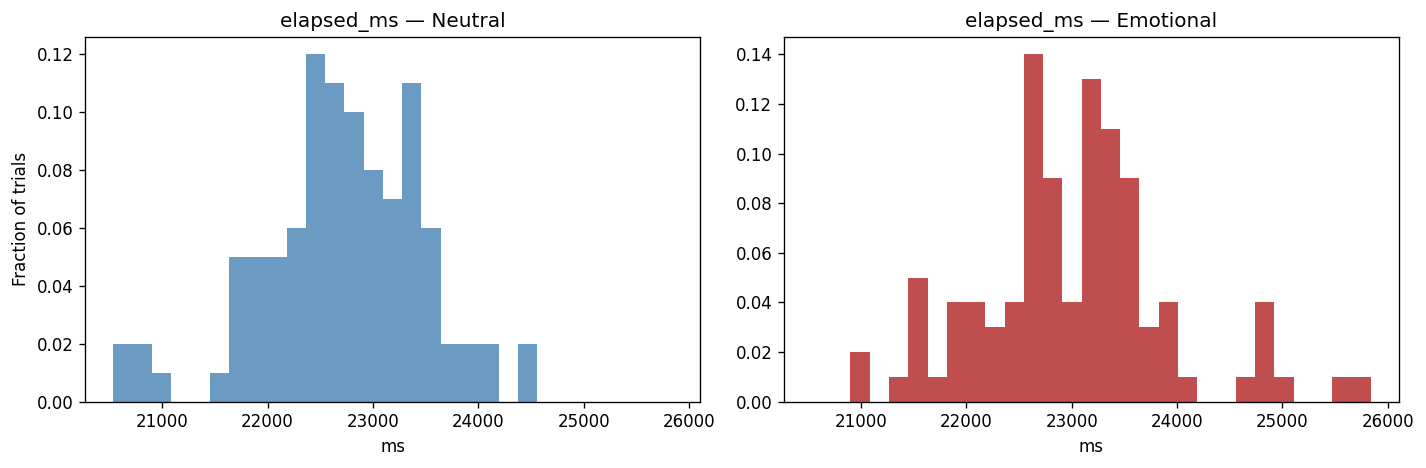


Length confound flag: LENGTH_CONFOUNDED = True
Note: mean_rate is normalised by dur_s — NOT confounded by length.
Metrics like variance, p90_p10, lz_complexity may scale with duration → flag if sig.


In [5]:
weights_n = np.ones(len(dur_n)) / len(dur_n)
weights_e = np.ones(len(dur_e)) / len(dur_e)

has_tokens = df_all['n_tokens'].notna().any()
n_panels = 4 if has_tokens else 2
fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 4))

axes[0].hist(dur_n, bins=bins, weights=weights_n, color='steelblue', alpha=0.8, label='neutral')
axes[0].set_title('elapsed_ms — Neutral')
axes[0].set_xlabel('ms'); axes[0].set_ylabel('Fraction of trials')

axes[1].hist(dur_e, bins=bins, weights=weights_e, color='firebrick', alpha=0.8, label='emotional')
axes[1].set_title('elapsed_ms — Emotional')
axes[1].set_xlabel('ms')

if has_tokens:
    tok_bins = np.linspace(df_all['n_tokens'].min(), df_all['n_tokens'].max(), 20)
    w_tn = np.ones(len(tok_n)) / len(tok_n)
    w_te = np.ones(len(tok_e)) / len(tok_e)
    axes[2].hist(tok_n, bins=tok_bins, weights=w_tn, color='steelblue', alpha=0.8)
    axes[2].set_title('n_tokens — Neutral')
    axes[2].set_xlabel('tokens'); axes[2].set_ylabel('Fraction of trials')
    axes[3].hist(tok_e, bins=tok_bins, weights=w_te, color='firebrick', alpha=0.8)
    axes[3].set_title('n_tokens — Emotional')
    axes[3].set_xlabel('tokens')

plt.tight_layout()
plt.show()

print(f'\nLength confound flag: LENGTH_CONFOUNDED = {LENGTH_CONFOUNDED}')
print('Note: mean_rate is normalised by dur_s — NOT confounded by length.')
print('Metrics like variance, p90_p10, lz_complexity may scale with duration → flag if sig.')
if has_tokens:
    print(f'n_tokens confounder: p={p_tok:.4g}  '
          + ('⚠ significant' if p_tok < 0.05 else '✓ not significant'))


## 5 — Feature selection

Three filtering steps are applied in sequence:

1. **Length-confounded metrics** — if `LENGTH_CONFOUNDED=True`, optionally exclude metrics
   not normalised by duration (`variance`, `p90_p10`, `lz_complexity`, `perm_entropy`, `spectral_entropy`).
2. **Artefact / noise indicators** — hard-exclude indicators that are measurement artefacts
   or pure OS noise unrelated to inference (`hat_PMI`, `hat_NMI`, `hat_LOC`, `hat_RES`,
   `hat_CAL`, `hat_MCP`, `cpu_freq`).
3. **Correlation pruning** — for each pair with |Pearson r| > 0.95, drop the lower-variance one.


In [6]:
# --- Feature selection: include/exclude length-confounded features ---
from typing import List

# List of metrics that may be length-confounded
LENGTH_CONFOUNDED_METRICS = {
    'variance', 'p90_p10', 'lz_complexity', 'perm_entropy', 'spectral_entropy'
}

feature_cols = [c for c in df_all.columns if '__' in c]

def metric_of(col: str) -> str:
    # evt__metric
    return col.split('__', 1)[1]

length_confounded_cols   = [c for c in feature_cols if metric_of(c) in LENGTH_CONFOUNDED_METRICS]
length_unconfounded_cols = [c for c in feature_cols if metric_of(c) not in LENGTH_CONFOUNDED_METRICS]

print(f"Length-confounded features: {len(length_confounded_cols)}")
print(f"Length-unconfounded features: {len(length_unconfounded_cols)}")

# User selection: set to True to include, False to exclude length-confounded features
INCLUDE_LENGTH_CONFOUNDED = True  # <-- change this to True to include them

if INCLUDE_LENGTH_CONFOUNDED:
    selected_cols = length_unconfounded_cols + length_confounded_cols
    print("Including ALL features (length-confounded and unconfounded).")
else:
    selected_cols = length_unconfounded_cols
    print("Excluding length-confounded features.")

# Subset the feature matrix for downstream analysis
X = df_all[selected_cols].copy()
print(f"Final feature matrix shape: {X.shape}")

Length-confounded features: 275
Length-unconfounded features: 275
Including ALL features (length-confounded and unconfounded).
Final feature matrix shape: (200, 550)


### Build and clean feature matrix

In [7]:
# --- Build feature matrix and clean ---
# Use selected_cols from previous cell (already filtered for confounding)

# n_tokens and title are metadata/confounders — exclude from feature matrix
META_COLS = {'condition', 'prompt_index', 'elapsed_ms', 'dur_s', 'n_tokens', 'title'}
feat_cols = [c for c in X.columns if c not in META_COLS]

X_raw = X[feat_cols].apply(pd.to_numeric, errors='coerce')
y = (df_all['condition'] == 'emotional').astype(int).values  # 0=neutral, 1=emotional

# Drop zero-variance columns and fill NaN
X_raw = X_raw.loc[:, X_raw.std() > 0]
X_raw = X_raw.fillna(X_raw.median())

feat_cols = list(X_raw.columns)
print(f'Feature matrix: {X_raw.shape[0]} samples × {X_raw.shape[1]} features')

# Standardise
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X_raw), columns=feat_cols)
print('Standardised.')

Feature matrix: 200 samples × 370 features
Standardised.


In [8]:
# ── Signal-quality mask ─────────────────────────────────────────────────────
# Based on the physiological interpretation of each hardware/OS counter.
# Indicators are the prefix before '__' in column names (e.g. hat_TLB, cache-misses).
#
# Tier 1 — Primary computation-coupled signals (direct inference substrate signals)
PRIMARY_SIGNALS = {
    'tlb:tlb_flush',          # hardware TLB shootdown — direct VM pressure
    'LLC-load-misses',        # DRAM fetches from model weight access
    'cache-misses',           # L1/L2 cache pressure from inference
    'cache-references',       # L1/L2 cache references
    'dTLB-load-misses',       # data TLB misses during weight tensor loads
    'branch-misses',          # branch predictor misses shaped by inference control flow
    'branch-instructions',    # total branch count
    'instructions',           # raw computational throughput
    'cycles',                 # CPU cycle count
    'core_power.throttle',    # thermal throttle from sustained inference load
}

# Tier 2 — Computation-coupled but indirect (keep, interpret with caveats)
INDIRECT_SIGNALS = {
    'power/energy-pkg/',      # RAPL package energy
    'power/energy-ram/',      # RAPL RAM energy
    'msr/cpu_thermal_margin/',# thermal margin (slow-moving, session-level)
    'irq:irq_handler_exit',   # all IRQ completions — inference-coupled but noisy
    'irq:softirq_raise',      # softirq scheduling — computation-coupled, aggregated
}

# Tier 3 — Confounder controls (keep but do NOT interpret as substrate signals)
CONFOUNDER_CONTROLS = {
    'context-switches',       # scheduling artefact; if differs, explains hw counter diffs
    'cpu-migrations',         # scheduling/migration artefact
    'page-faults',            # mmap weight access (minor) + noise (major)
    'cpu-clock',              # duration normaliser
}

# Tier 4 — HAT substrate signals (hat__ prefix indicators to keep)
HAT_PRIMARY = {
    'hat_TLB',   # TLB shootdown IPIs — direct VM pressure from inference
    'hat_BLOCK', # block I/O softirq — memory pressure / page reclaim during weight access
    'hat_IWI',   # interprocessor wakeup IRQs — NUMA memory access patterns
}

# Tier 5 — HAT scheduling-coupled (keep with caveats)
HAT_SCHEDULING = {
    'hat_NET_RX',  # scheduler side-effect of CPU occupancy
    'hat_NET_TX',
    'hat_SCHED',   # scheduler softirq — modulated by inference CPU demand
    'hat_RCU',     # RCU callbacks — loosely correlated with kernel activity
    'hat_TIMER',   # timer softirq — partially fixed-rate, partially load-dependent
}

# Exclude — measurement artefact or pure OS noise unrelated to inference
EXCLUDE_INDICATORS = {
    'hat_PMI',   # perf's own sampling interrupts — artefact, not inference-related
    'hat_NMI',   # non-maskable interrupt counts — hardware artefact
    'hat_LOC',   # local APIC timer — fires at fixed kernel tick rate, ignores inference
    'hat_RES',   # rescheduling IPIs — scheduler load balancing, not inference
    'hat_CAL',   # function-call IPIs — OS housekeeping
    'hat_MCP',   # machine check polls — periodic kernel health, not inference-driven
    'cpu_freq',  # DVFS governor — consequence of power policy, not a substrate signal
}

def _indicator_of(col: str) -> str:
    """Return the indicator prefix of a column named 'indicator__metric'."""
    return col.split('__', 1)[0]

_before = len(feat_cols)
feat_cols = [
    c for c in feat_cols
    if _indicator_of(c) not in EXCLUDE_INDICATORS
]
_excluded = _before - len(feat_cols)

X_raw = X_raw[feat_cols].copy()
X     = X[feat_cols].copy()

print(f'Signal-quality mask:')
print(f'  Excluded {_excluded} columns from {_before} '
      f'({", ".join(sorted(EXCLUDE_INDICATORS))})')
print(f'  Remaining: {len(feat_cols)} features')


Signal-quality mask:
  Excluded 54 columns from 370 (cpu_freq, hat_CAL, hat_LOC, hat_MCP, hat_NMI, hat_PMI, hat_RES)
  Remaining: 316 features


In [9]:

"""# ── Correlation pruning ──────────────────────────────────────────────
# For each pair of features with |Pearson r| > 0.95, drop the one with
# lower variance (less informative), keeping the more variable one.
CORR_THRESHOLD = 0.95

corr_matrix = X_raw.corr().abs()
# Upper triangle only (avoid double-counting pairs)
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1)
)

# For each column, collect all its partners that exceed threshold
# Sort features by variance descending so we always keep the most variable
feat_var = X_raw.var().sort_values(ascending=False)
ordered  = feat_var.index.tolist()   # high-variance features first

to_drop = set()
for feat in ordered:
    if feat in to_drop:
        continue
    # Partners with correlation > threshold that haven't been dropped yet
    partners = upper.index[upper[feat] > CORR_THRESHOLD].tolist() if feat in upper.columns else []
    for partner in partners:
        if partner not in to_drop:
            # Drop the lower-variance one (partner comes later in `ordered`)
            to_drop.add(partner)

X_raw    = X_raw.drop(columns=list(to_drop))
feat_cols = list(X_raw.columns)

# Re-standardise after pruning
X = pd.DataFrame(scaler.fit_transform(X_raw), columns=feat_cols)

print(f'Correlation pruning (|r| > {CORR_THRESHOLD}):')
print(f'  Dropped : {len(to_drop)} features')
print(f'  Kept    : {len(feat_cols)} features')"""


"# ── Correlation pruning ──────────────────────────────────────────────\n# For each pair of features with |Pearson r| > 0.95, drop the one with\n# lower variance (less informative), keeping the more variable one.\nCORR_THRESHOLD = 0.95\n\ncorr_matrix = X_raw.corr().abs()\n# Upper triangle only (avoid double-counting pairs)\nupper = corr_matrix.where(\n    np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1)\n)\n\n# For each column, collect all its partners that exceed threshold\n# Sort features by variance descending so we always keep the most variable\nfeat_var = X_raw.var().sort_values(ascending=False)\nordered  = feat_var.index.tolist()   # high-variance features first\n\nto_drop = set()\nfor feat in ordered:\n    if feat in to_drop:\n        continue\n    # Partners with correlation > threshold that haven't been dropped yet\n    partners = upper.index[upper[feat] > CORR_THRESHOLD].tolist() if feat in upper.columns else []\n    for partner in partners:\n        if partner not in to

In [10]:
# --- Diagnostics: Check feature selection logic ---
print(f"INCLUDE_LENGTH_CONFOUNDED = {INCLUDE_LENGTH_CONFOUNDED}")
print(f"Length-confounded features matched: {len(length_confounded_cols)}")
print(f"Length-unconfounded features matched: {len(length_unconfounded_cols)}")
print(f"Selected columns: {len(selected_cols)}")
print(f"Final feature matrix shape after cleaning: {X.shape}")

INCLUDE_LENGTH_CONFOUNDED = True
Length-confounded features matched: 275
Length-unconfounded features matched: 275
Selected columns: 550
Final feature matrix shape after cleaning: (200, 316)


## 5b — HAT Layer 1 audit: genuine hardware anomaly indicators

The collector captures true hardware anomaly interrupts from `/proc/interrupts` as separate
named indicators — distinct from the aggregate `irq:irq_handler_entry/exit` tracepoints.

According to the HAT definition these are:

| Indicator | HAT type |
|---|---|
| `hat_SPU` | Spurious interrupt |
| `hat_MCE` | Machine Check Exception |
| `hat_NMI` | Non-Maskable Interrupt (perf counter overflow) |
| `hat_PMI` | Performance Monitoring Interrupt (perf overflow) |
| `hat_TLB` | TLB Shootdown |
| `hat_MCP` | Machine Check Poll |

**Expected behaviour on a healthy node:** most of these will be near-zero for every trial.
This section audits whether any signal exists, and whether the zero-rate indicators can be
distinguished from the Layer 2 continuous metrics that do show signal.

### What this section does

We audit the six **HAT Layer 1** indicators — the genuine hardware anomaly signals
the professor's definition names — and compare them against three **Layer 2** continuous
metrics that actually show discriminative power.

For each indicator we ask:
1. Is it present in the data at all?
2. Is it all-zero (healthy node) or does it have signal?
3. For the non-zero ones: does the distribution differ between neutral and emotional trials?

We do this **per run** (A, B, D, E, F separately) so we can see how many data points
each feature has in each run, and whether any signal is consistent or run-specific.

A final summary cell pools all five runs and identifies which indicators are
worth reporting to the professor.

**Indicators we focus on:**

| Indicator | HAT Layer 1 type | Expected on healthy node |
|---|---|---|
| `hat_SPU` | Spurious interrupt | ~0 |
| `hat_MCE` | Machine Check Exception | 0 |
| `hat_NMI` | Non-Maskable Interrupt | ~0 |
| `hat_PMI` | Performance Monitoring Interrupt | ~0 |
| `hat_TLB` | TLB Shootdown | **may have signal** — inference generates VM pressure |
| `hat_MCP` | Machine Check Poll | 0 |

**Layer 2 reference indicators** (known to carry signal, shown for comparison):
`dTLB-load-misses`, `cache-misses`, `cache-references`

In [ ]:
# ── §5b Per-run HAT Layer 1 audit — full indicator × metric grid ─────────────
# For each run and each HAT indicator we test ALL 10 metrics, not just mean_rate.
# For the all-zero indicators (SPU, MCE, MCP) this changes nothing.
# For hat_TLB and any L2 refs it may reveal metrics that discriminate
# even when mean_rate does not.
#
# For each run we print:
#   - how many data points (N neutral, E emotional) per indicator
#   - for each metric: whether it has signal, MWU p-value, direction
#   - a strip plot for the best metric per indicator (lowest p-value)

from scipy.stats import mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

HAT_L1 = ['hat_SPU', 'hat_MCE', 'hat_NMI', 'hat_PMI', 'hat_TLB', 'hat_MCP']
HAT_L2_REF = ['dTLB-load-misses', 'cache-misses', 'cache-references']
ALL_FOCUS = HAT_L1 + HAT_L2_REF

ALL_METRICS = [
    'mean_rate', 'variance', 'p90_p10', 'slope',
    'spectral_entropy', 'iat_cv', 'burst_rate',
    'burst_clustering', 'lz_complexity', 'perm_entropy'
]


def audit_run_full(df, run_label):
    print()
    print(f"{'='*80}")
    print(f"  RUN {run_label}  —  {len(df)} trials  "
          f"(neutral: {(df.condition=='neutral').sum()}, "
          f"emotional: {(df.condition=='emotional').sum()})")
    print(f"{'='*80}")

    best_per_ind = []   # collect best metric per indicator for strip plots

    for ind in ALL_FOCUS:
        layer = 'L1' if ind in HAT_L1 else 'L2'

        # Count data points from any column for this indicator
        any_col = next((f"{ind}__{m}" for m in ALL_METRICS
                        if f"{ind}__{m}" in df.columns), None)
        if any_col is None:
            print(f"  [{layer}] {ind:<28} — NOT IN DATA")
            continue

        n_count = (df.condition == 'neutral').sum()
        e_count = (df.condition == 'emotional').sum()
        print(f"  [{layer}] {ind:<28}  data points: {n_count} neutral, {e_count} emotional")
        print(f"         {'Metric':<20} {'n(N)':>5} {'n(E)':>5}  "
              f"{'Neutral mean':>14}  {'Emot. mean':>14}  {'p-value':>10}  {'Dir':>4}  Note")
        print(f"         {'-'*85}")

        metric_results = []
        for metric in ALL_METRICS:
            col = f"{ind}__{metric}"
            if col not in df.columns:
                print(f"         {metric:<20} {'—':>5} {'—':>5}  {'—':>14}  {'—':>14}  {'—':>10}  {'—':>4}  missing")
                continue

            n_vals = pd.to_numeric(df.loc[df.condition=='neutral',   col], errors='coerce').dropna()
            e_vals = pd.to_numeric(df.loc[df.condition=='emotional', col], errors='coerce').dropna()

            if len(n_vals) < 3 or len(e_vals) < 3:
                print(f"         {metric:<20} {len(n_vals):>5} {len(e_vals):>5}  "
                      f"{'—':>14}  {'—':>14}  {'—':>10}  {'—':>4}  insufficient n")
                continue

            all_zero = (pd.concat([n_vals, e_vals]).abs() < 1e-9).all()
            if all_zero:
                print(f"         {metric:<20} {len(n_vals):>5} {len(e_vals):>5}  "
                      f"{0.0:>14.4g}  {0.0:>14.4g}  {'—':>10}  {'—':>4}  ALL ZERO")
                continue

            _, p = mannwhitneyu(n_vals, e_vals, alternative='two-sided')
            direction = '↑E' if e_vals.mean() > n_vals.mean() else '↓E'
            star = '★' if p < 0.05 else ''
            note = f"SIG{star}" if p < 0.05 else ''
            print(f"         {metric:<20} {len(n_vals):>5} {len(e_vals):>5}  "
                  f"{n_vals.mean():>14.4g}  {e_vals.mean():>14.4g}  "
                  f"{p:>10.4f}  {direction:>4}  {note}")

            metric_results.append({
                'metric': metric, 'col': col,
                'n_vals': n_vals, 'e_vals': e_vals,
                'p': p, 'direction': direction
            })

        print()

        # Keep best metric (lowest p) for strip plot
        if metric_results:
            best = min(metric_results, key=lambda r: r['p'])
            best_per_ind.append({'ind': ind, 'layer': layer, **best})

    # Strip plots: best metric per indicator (non-zero only)
    plot_rows = [r for r in best_per_ind
                 if not (pd.concat([r['n_vals'], r['e_vals']]).abs() < 1e-9).all()]

    if not plot_rows:
        print(f"  → All Layer 1 indicators are zero. Showing Layer 2 refs only.")
        plot_rows = [r for r in best_per_ind if r['layer'] == 'L2']

    if plot_rows:
        n_plots = len(plot_rows)
        fig, axes = plt.subplots(1, n_plots, figsize=(5.5 * n_plots, 5.5))
        if n_plots == 1:
            axes = [axes]
        rng = np.random.default_rng(42)

        for ax, r in zip(axes, plot_rows):
            n_vals = r['n_vals'].values
            e_vals = r['e_vals'].values
            for x_pos, vals, color, label in [
                    (0, n_vals, 'steelblue', 'Neutral'),
                    (1, e_vals, 'firebrick', 'Emotional')]:
                jitter = rng.uniform(-0.18, 0.18, len(vals))
                ax.scatter(np.full(len(vals), x_pos) + jitter, vals,
                           color=color, alpha=0.6, s=25, zorder=3, label=label)
                ax.plot([x_pos-0.2, x_pos+0.2],
                        [np.median(vals), np.median(vals)],
                        color=color, lw=2.5, zorder=4)

            ax.set_xticks([0, 1])
            ax.set_xticklabels([f"N\n(n={len(n_vals)})", f"E\n(n={len(e_vals)})"],
                               fontsize=10)
            ax.set_title(f"{r['ind']}\n[{r['layer']}]  best: {r['metric']}", fontsize=11)
            ax.set_ylabel(r['metric'], fontsize=10)
            ax.spines[['top','right']].set_visible(False)

            pooled = np.concatenate([n_vals, e_vals])
            d = ((e_vals.mean()-n_vals.mean())/pooled.std(ddof=1)
                 if pooled.std(ddof=1) > 0 else 0.0)
            ax.text(0.03, 0.97,
                    f"p={r['p']:.3g}\nCohen d={d:.2f}\ndir: {r['direction']}",
                    transform=ax.transAxes, ha='left', va='top', fontsize=10,
                    bbox=dict(facecolor='white', alpha=0.8,
                              edgecolor='#ccc', boxstyle='round'))

        handles = [plt.Line2D([0],[0], marker='o', color='w',
                               markerfacecolor=c, markersize=9, label=l)
                   for c, l in [('steelblue','Neutral'),('firebrick','Emotional')]]
        fig.legend(handles=handles, loc='upper right', fontsize=10)
        plt.suptitle(f"Run {run_label} — best metric per indicator", fontsize=14, y=1.01)
        plt.tight_layout()
        plt.show()

    return best_per_ind


all_run_best = {}
for run in RUNS:
    all_run_best[run] = audit_run_full(dfs_by_run[run], run)


### Cross-run summary

Each run is independent (different day, same node). We now ask:

- Which indicators appear consistently across all 5 runs with actual values (not zero)?
- Which show a consistent direction (always ↑E or always ↓E)?
- Which reach p < 0.05 in at least one run?

This is the key table for the professor: it distinguishes **genuine hardware anomaly
signals** (Layer 1) from **continuous performance metrics** (Layer 2), and shows
honestly how often each one fires on a healthy node.

In [ ]:
# ── §5b Cross-run summary — full indicator × metric grid ─────────────────────
# For each indicator we find the best metric (lowest p-value) in each run,
# then summarise consistency across all 5 runs.
#
# Columns:
#   Runs w/ data  — how many of the 5 runs have this indicator at all
#   Non-zero      — how many runs have at least one non-zero value
#   Best metric   — the metric that most often wins (lowest p) across runs
#   p<.05 runs    — how many runs the best metric clears significance in
#   Direction     — consistent ↑E / ↓E, or mixed
#   Best p        — lowest single-run p-value seen for any metric

from scipy.stats import mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

HAT_L1     = ['hat_SPU', 'hat_MCE', 'hat_NMI', 'hat_PMI', 'hat_TLB', 'hat_MCP']
HAT_L2_REF = ['dTLB-load-misses', 'cache-misses', 'cache-references']
ALL_FOCUS  = HAT_L1 + HAT_L2_REF

ALL_METRICS = [
    'mean_rate', 'variance', 'p90_p10', 'slope',
    'spectral_entropy', 'iat_cv', 'burst_rate',
    'burst_clustering', 'lz_complexity', 'perm_entropy'
]


def best_metric_for_ind(df, ind):
    """Return dict of {metric: {p, direction, n_n, n_e}} for all valid metrics."""
    results = {}
    for metric in ALL_METRICS:
        col = f"{ind}__{metric}"
        if col not in df.columns:
            continue
        n_vals = pd.to_numeric(df.loc[df.condition=='neutral',   col], errors='coerce').dropna()
        e_vals = pd.to_numeric(df.loc[df.condition=='emotional', col], errors='coerce').dropna()
        if len(n_vals) < 3 or len(e_vals) < 3:
            continue
        if (pd.concat([n_vals, e_vals]).abs() < 1e-9).all():
            continue   # all-zero — skip
        _, p = mannwhitneyu(n_vals, e_vals, alternative='two-sided')
        results[metric] = {
            'p': p,
            'direction': '↑E' if e_vals.mean() > n_vals.mean() else '↓E',
            'n_n': len(n_vals),
            'n_e': len(e_vals),
        }
    return results   # empty dict if all-zero or missing


# ── Build summary ─────────────────────────────────────────────────────────────
summary_rows = []

for ind in ALL_FOCUS:
    layer = 'L1' if ind in HAT_L1 else 'L2'

    run_best = {}   # run -> {metric, p, direction, n_n, n_e}
    for run in RUNS:
        res = best_metric_for_ind(dfs_by_run[run], ind)
        if res:
            best_m = min(res, key=lambda m: res[m]['p'])
            run_best[run] = {'metric': best_m, **res[best_m]}

    # Count presence (any column for this indicator exists)
    n_runs_present = sum(
        1 for run in RUNS
        if any(f"{ind}__{m}" in dfs_by_run[run].columns for m in ALL_METRICS)
    )
    n_runs_nonzero = len(run_best)
    n_runs_sig     = sum(1 for r in run_best.values() if r['p'] < 0.05)

    # Most common best metric
    from collections import Counter
    metric_votes   = Counter(r['metric'] for r in run_best.values())
    top_metric     = metric_votes.most_common(1)[0][0] if metric_votes else '—'

    directions     = [r['direction'] for r in run_best.values()]
    sign_consistent = len(set(directions)) == 1 if directions else False
    sign_mode      = directions[0] if sign_consistent and directions else ('mixed' if directions else '—')

    all_ps         = [r['p'] for r in run_best.values()]
    best_p         = min(all_ps) if all_ps else float('nan')

    dp_str = '  '.join(
        f"{run}:{run_best[run]['n_n']}N/{run_best[run]['n_e']}E"
        if run in run_best else f"{run}:zero"
        for run in RUNS
    )

    summary_rows.append({
        'indicator': ind, 'layer': layer,
        'n_runs_present': n_runs_present,
        'n_runs_nonzero': n_runs_nonzero,
        'n_runs_sig': n_runs_sig,
        'top_metric': top_metric,
        'sign_mode': sign_mode,
        'sign_consistent': sign_consistent,
        'best_p': best_p,
        'dp_str': dp_str,
        'run_best': run_best,
    })

# ── Print summary table ───────────────────────────────────────────────────────
print("=" * 90)
print("CROSS-RUN SUMMARY — best metric per indicator across 5 runs")
print(f"Runs: {', '.join(RUNS)}")
print("=" * 90)
print()
print(f"  {'Lyr':<3} {'Indicator':<28} {'Runs w/data':>11} {'Non-zero':>9} "
      f"{'p<.05 runs':>10} {'Best metric':<22} {'Direction':>10} {'Best p':>10}")
print(f"  {'-'*100}")

for r in summary_rows:
    bp  = f"{r['best_p']:.4f}" if not pd.isna(r['best_p']) else '—'
    sig = '★' if r['n_runs_sig'] > 0 else ''
    print(f"  {r['layer']:<3} {r['indicator']:<28} "
          f"{r['n_runs_present']:>11} {r['n_runs_nonzero']:>9} "
          f"{r['n_runs_sig']:>10} {r['top_metric']:<22} "
          f"{r['sign_mode']:>10} {bp:>9}{sig}")

print()
print("Data points per run (zero = indicator was all-zero in that run):")
for r in summary_rows:
    print(f"  {r['indicator']:<28}  {r['dp_str']}")

# ── Per-indicator best-metric detail ─────────────────────────────────────────
print()
print("=" * 90)
print("BEST METRIC PER INDICATOR PER RUN (non-zero runs only)")
print("=" * 90)
for r in summary_rows:
    if not r['run_best']:
        print(f"  {r['layer']} {r['indicator']:<28} — all zero in all runs")
        continue
    print(f"  {r['layer']} {r['indicator']}")
    for run, rb in r['run_best'].items():
        star = '★' if rb['p'] < 0.05 else ' '
        print(f"       Run {run}: best={rb['metric']:<22} "
              f"p={rb['p']:.4f}{star}  dir={rb['direction']}  "
              f"n={rb['n_n']}N/{rb['n_e']}E")

# ── Interpretation ────────────────────────────────────────────────────────────
print()
print("=" * 90)
print("INTERPRETATION")
print("=" * 90)

l1_allzero = [r for r in summary_rows if r['layer']=='L1' and r['n_runs_nonzero']==0]
l1_nonzero = [r for r in summary_rows if r['layer']=='L1' and r['n_runs_nonzero'] > 0]
l2_sig     = [r for r in summary_rows if r['layer']=='L2' and r['n_runs_sig'] > 0]

print()
if l1_allzero:
    print(f"Layer 1 — always zero ({len(l1_allzero)} indicators):")
    for r in l1_allzero:
        print(f"  {r['indicator']:<28} → zero across all runs and all metrics")
    print("  → Healthy node confirmed. No spurious, MCE, NMI, PMI, or MCP events.")

if l1_nonzero:
    print(f"\nLayer 1 — has signal ({len(l1_nonzero)} indicators):")
    for r in l1_nonzero:
        sig_note = (f"significant in {r['n_runs_sig']}/5 runs"
                    if r['n_runs_sig'] else "not significant in any run")
        print(f"  {r['indicator']:<28} → non-zero in {r['n_runs_nonzero']}/5 runs, "
              f"{sig_note}, best metric: {r['top_metric']}, direction: {r['sign_mode']}")
else:
    print("\n→ All HAT Layer 1 indicators are zero for every metric in every run.")
    print("  Signal discrimination lives entirely in Layer 2.")

print()
if l2_sig:
    print(f"Layer 2 — significant in ≥1 run ({len(l2_sig)} indicators):")
    for r in l2_sig:
        print(f"  {r['indicator']:<28} → p<.05 in {r['n_runs_sig']}/5 runs, "
              f"best metric: {r['top_metric']}, direction: {r['sign_mode']}, "
              f"best p={r['best_p']:.4f}")

# ── Heatmap: best p per (indicator, run) ─────────────────────────────────────
heat_data = []
annot_data = []

for r in summary_rows:
    row_logp = []
    row_ann  = []
    for run in RUNS:
        if run in r['run_best']:
            rb = r['run_best'][run]
            row_logp.append(-np.log10(max(rb['p'], 1e-10)))
            star = '★' if rb['p'] < 0.05 else ''
            row_ann.append(f"{rb['direction']}{star}\n{rb['metric'][:8]}")
        else:
            row_logp.append(float('nan'))
            row_ann.append('0')
    heat_data.append(row_logp)
    annot_data.append(row_ann)

heat_arr     = np.array(heat_data, dtype=float)
heat_masked  = np.ma.masked_invalid(heat_arr)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(heat_masked, aspect='auto', cmap='YlOrRd', vmin=0, vmax=4)

ax.set_xticks(range(len(RUNS)))
ax.set_xticklabels([f"Run {r}" for r in RUNS], fontsize=11)
ax.set_yticks(range(len(ALL_FOCUS)))
ax.set_yticklabels(ALL_FOCUS, fontsize=11)

# L1 / L2 separator
ax.axhline(len(HAT_L1) - 0.5, color='black', lw=1.5, ls='--')
ax.text(len(RUNS) - 0.45, len(HAT_L1) - 0.65,
        'L1 ↑ / L2 ↓', fontsize=9, ha='right', va='bottom')

# Annotate each cell with direction + best metric name (truncated)
for i in range(len(ALL_FOCUS)):
    for j in range(len(RUNS)):
        txt = annot_data[i][j]
        color = 'white' if (not np.isnan(heat_arr[i,j]) and heat_arr[i,j] > 2) else 'black'
        ax.text(j, i, txt, ha='center', va='center', fontsize=8, color=color)

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('−log₁₀(best p per run)', fontsize=11)
cbar.ax.tick_params(labelsize=10)

ax.set_title(
    "HAT Layer 1 + Layer 2: best metric p-value per run\n"
    "(cell shows direction★ and metric name; 0 = all-zero; darker = more significant)",
    fontsize=12, pad=12
)
plt.tight_layout()
plt.show()
